In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [3]:
train=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test=pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

In [4]:
train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [5]:
train.shape

(42000, 785)

In [6]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [8]:
X=train.drop('label', axis=1)
y=train['label']

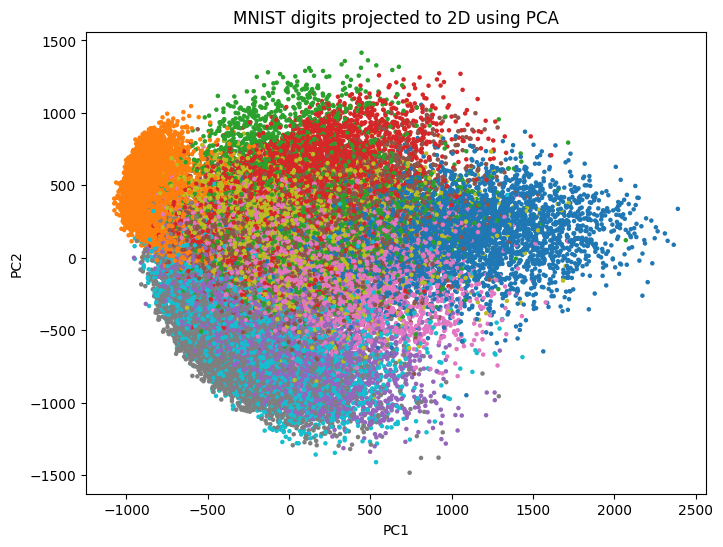

In [25]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=5)

plt.title("MNIST digits projected to 2D using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

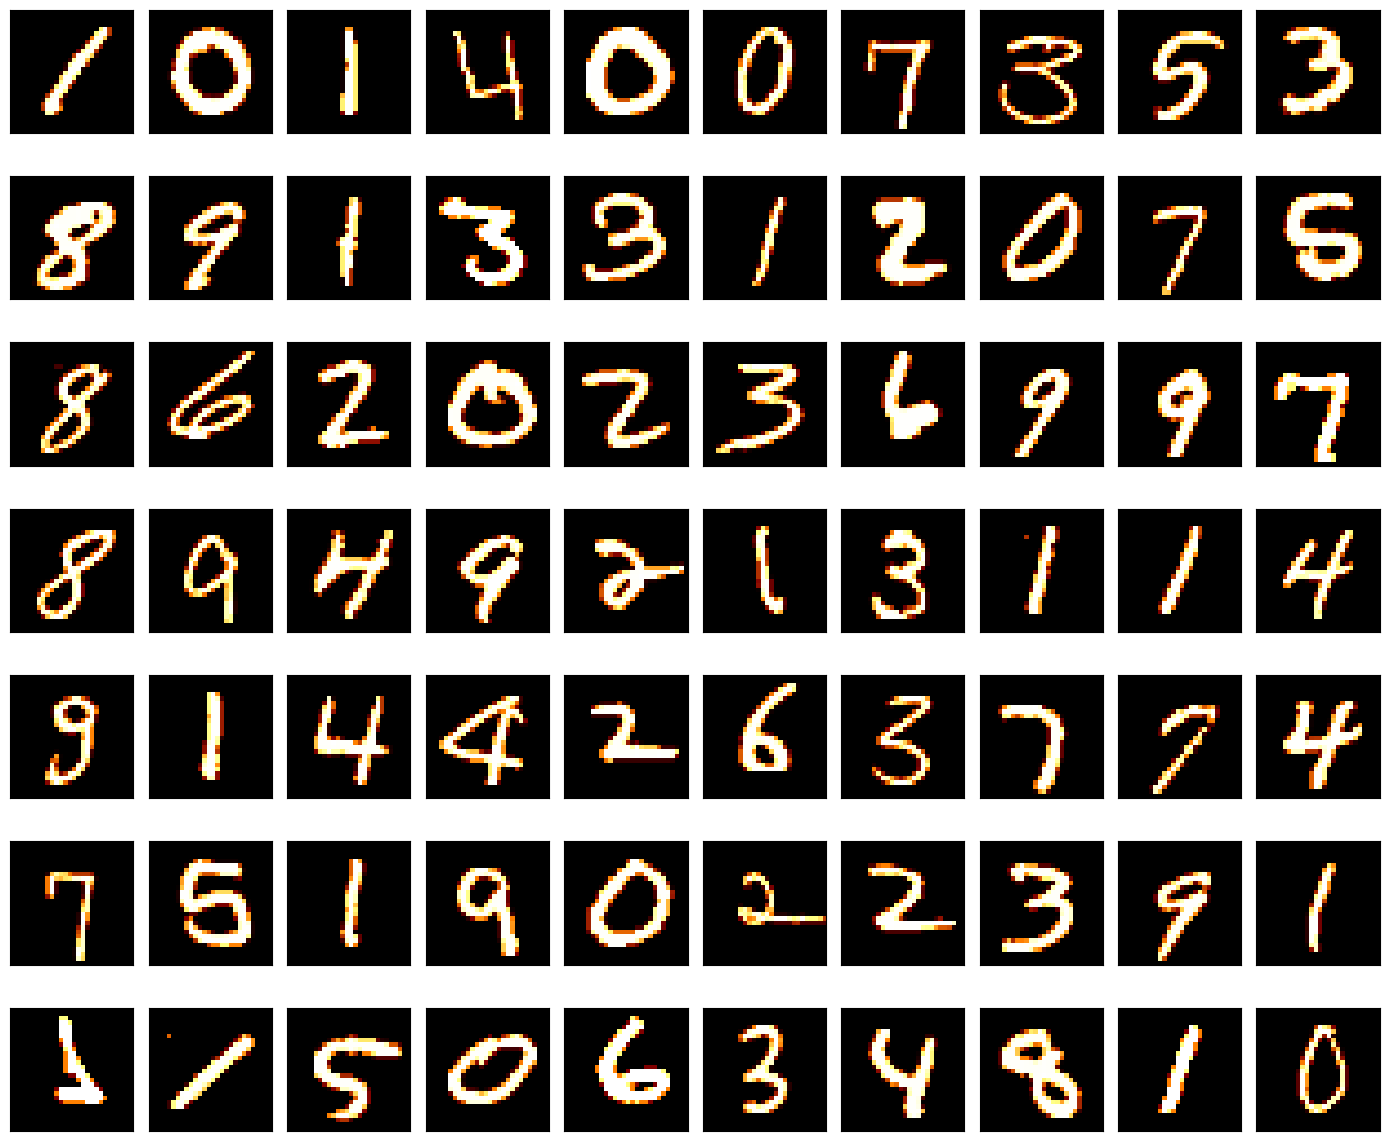

In [9]:
# plot some of the numbers
import matplotlib.pyplot as plt
plt.figure(figsize=(14,12))
for digit_num in range(0,70):
    plt.subplot(7,10,digit_num+1)
    grid_data = pd.to_numeric(X.iloc[digit_num]).values.reshape(28,28)  # reshape from 1d to 2d pixel array
    plt.imshow(grid_data, interpolation = "none", cmap = "afmhot")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2, random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)

In [12]:
X_test_scaled=scaler.transform(test)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

In [14]:
X_test_pca=pca.transform(X_test_scaled)

In [15]:
from sklearn.svm import SVC

linear_svm=SVC(kernel='linear')

linear_svm.fit(X_train_pca,y_train)


SVC(kernel='linear')

In [16]:

from sklearn.metrics import accuracy_score

y_pred = linear_svm.predict(X_train_pca)

acc = accuracy_score(y_train, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9374404761904762


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.2),
        np.arange(y_min, y_max, 0.2)
    )

    # create grid with 50 features
    grid = np.zeros((xx.ravel().shape[0], X.shape[1]))
    
    # fill first two PCA components
    grid[:,0] = xx.ravel()
    grid[:,1] = yy.ravel()

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

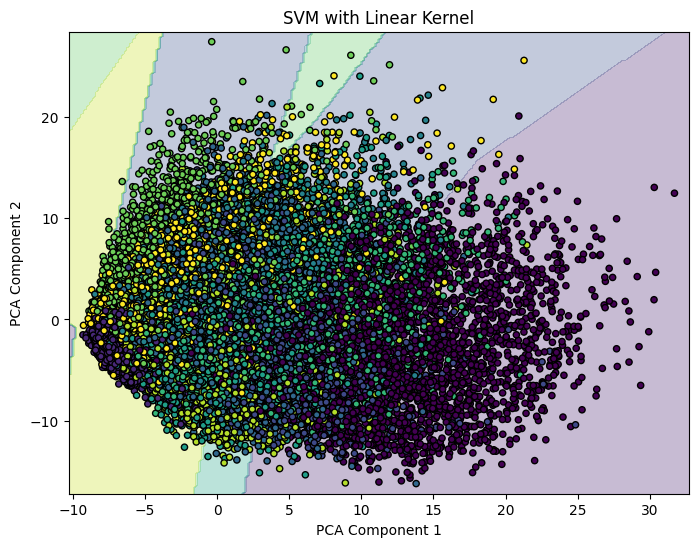

In [18]:

plot_decision_boundary(linear_svm, X_train_pca, y_train, "SVM with Linear Kernel")

In [19]:
rbf_svm=SVC(kernel='rbf', C=5, gamma='scale')

rbf_svm.fit(X_train_pca,y_train)

SVC(C=5)

In [20]:

y_pred_rbf = rbf_svm.predict(X_train_pca)

acc = accuracy_score(y_train, y_pred_rbf)

print("Accuracy:", acc)

Accuracy: 0.9927678571428571


In [26]:
print("Support vectors per class:", rbf_svm.n_support_)

Support vectors per class: [470 243 856 894 642 776 530 792 798 894]


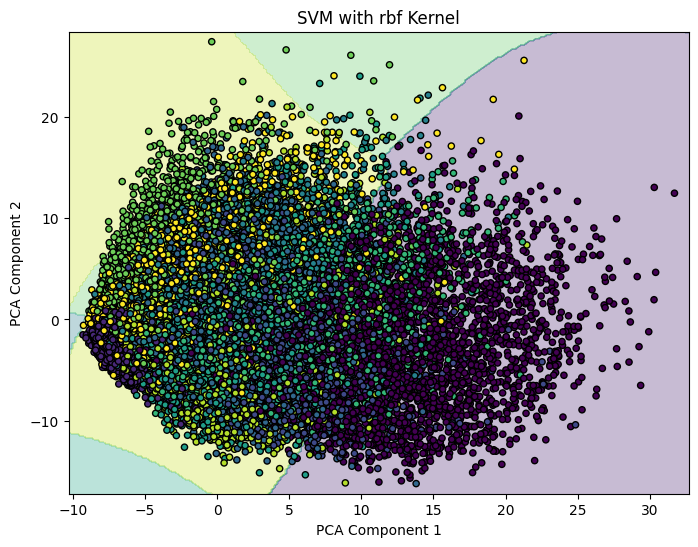

In [24]:
plot_decision_boundary(rbf_svm, X_train_pca, y_train, "SVM with rbf Kernel")

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_val, y_val))

Random Forest Accuracy: 0.9644047619047619


In [31]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=20)

mlp.fit(X_train_pca, y_train)

print("MLP Accuracy:", mlp.score(X_val_pca, y_val))

MLP Accuracy: 0.9648809523809524


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [32]:
# CNN implementation 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

2026-03-13 10:41:02.292912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773398462.568018      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773398462.647843      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773398463.315200      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773398463.315313      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773398463.315320      55 computation_placer.cc:177] computation placer alr

In [33]:
# normalize pixels
X_cnn = X.values / 255.0
test_cnn = test.values / 255.0

# reshape into images
X_cnn = X_cnn.reshape(-1,28,28,1)
test_cnn = test_cnn.reshape(-1,28,28,1)

# onehot encoding
y_cnn = to_categorical(y,10)

# spliting again for CNN
from sklearn.model_selection import train_test_split

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(X_cnn, y_cnn, test_size=0.2, random_state=0)

In [34]:
cnn_model = Sequential([
    
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    
    Dense(128,activation='relu'),
    Dropout(0.3),
    
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-13 10:42:34.226327: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [35]:
cnn_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [36]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_cnn,y_val_cnn)
)

Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8233 - loss: 0.5701 - val_accuracy: 0.9773 - val_loss: 0.0760
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9728 - loss: 0.0867 - val_accuracy: 0.9850 - val_loss: 0.0511
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9823 - loss: 0.0577 - val_accuracy: 0.9835 - val_loss: 0.0514
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9871 - val_loss: 0.0451
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9887 - loss: 0.0359 - val_accuracy: 0.9885 - val_loss: 0.0383
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9914 - loss: 0.0275 - val_accuracy: 0.9865 - val_loss: 0.0395
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9922 - loss: 0.0248 - val_accuracy: 0.9898 - val_loss: 0.0357
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9935 - loss: 0.0219 - 

In [37]:
loss, acc = cnn_model.evaluate(X_val_cnn,y_val_cnn)

print("CNN Accuracy:",acc)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9897 - loss: 0.0391
CNN Accuracy: 0.9895238280296326


In [22]:
#y_pred_rbf_test= rbf_svm.predict(X_test_pca)

In [23]:
# submission file
'''
submission = pd.DataFrame({
    "ImageId": range(1, len(y_pred_rbf_test)+1),
    "Label": y_pred_rbf_test
})

submission.to_csv("submission.csv", index=False)

print("Submitted successfully")
'''

Submitted successfully


In [39]:
pred = cnn_model.predict(test_cnn)

import numpy as np
pred_labels = np.argmax(pred,axis=1)

submission_cnn = pd.DataFrame({
    "ImageId": range(1,len(pred_labels)+1),
    "Label": pred_labels
})

submission_cnn.to_csv("submission.csv",index=False)
print("Submitted successfully")

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Submitted successfully
